# AAI-520 Final Team Project
## Member 1 (Ahmed): Data, APIs, and Prompt Chaining

**Student:** Ahmed Eldahmy  


**GitHub:** https://github.com/Ahmedeldahmy/AAI-520-Multi-Agent-Financial-Analysis



## Progress

- Step 1: GitHub setup - Done
- Step 2: Module 4 status form - Done
- Step 3: Notebook setup - Done
- Step 4: Yahoo Finance connection - Done
- Step 5: Financial news connection - Done
- Step 6: Prompt Chaining - Done
- Step 7: Test Member 1 tools - Done
- Step 8: Run the full pipeline - Done
- Step 9: Save results - Done


# Step 3: Setup

Install the packages and load the libraries.


In [ ]:
!pip -q install -U yfinance curl_cffi langgraph langchain-openai pydantic



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import re
import json
import time
import logging
import datetime
import warnings

warnings.filterwarnings("ignore")

# Hide noisy yfinance messages. Our code returns its own clean errors.
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import pandas as pd
import yfinance as yf

from typing import Literal, Optional, TypedDict
from pydantic import BaseModel, Field

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

print("Setup complete.")

Setup complete.


In [ ]:
print("pandas version:", pd.__version__)
print("yfinance version:", yf.__version__)


pandas version: 3.0.3
yfinance version: 1.7.0


In [ ]:
# Project settings

MAX_NEWS_ARTICLES = 5
STOCK_HISTORY_PERIOD = "1mo"

MAX_RETRIES = 3
RETRY_WAIT_SECONDS = 2

LLM_MODEL = "gpt-6-luna"

TEST_SYMBOLS = [
    "AAPL",
    "MSFT",
    "NVDA",
    "SPYFAKE"
]

print("Settings loaded.")

Settings loaded.


# Step 4: Yahoo Finance

This step pulls price history, company information, and recent earnings.

The price request retries automatically. Company information is handled separately so one Yahoo response does not stop the full result.

In [ ]:
def _sleep_before_retry(attempt: int) -> None:
    """Wait before another Yahoo request."""
    if attempt < MAX_RETRIES:
        time.sleep(RETRY_WAIT_SECONDS)


def _download_price_history(symbol: str) -> pd.DataFrame:
    """Download recent price history with retry and fallback."""
    last_error = None

    # First try yf.download.
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            history = yf.download(
                symbol,
                period=STOCK_HISTORY_PERIOD,
                interval="1d",
                progress=False,
                auto_adjust=False,
                threads=False
            )

            if history is not None and not history.empty:
                if isinstance(history.columns, pd.MultiIndex):
                    history.columns = history.columns.get_level_values(0)

                return history

        except Exception as exc:
            last_error = exc

        _sleep_before_retry(attempt)

    # Fallback to Ticker.history.
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            ticker = yf.Ticker(symbol)

            history = ticker.history(
                period=STOCK_HISTORY_PERIOD,
                interval="1d",
                auto_adjust=False
            )

            if history is not None and not history.empty:
                return history

        except Exception as exc:
            last_error = exc

        _sleep_before_retry(attempt)

    if last_error:
        raise RuntimeError(
            f"Yahoo price request failed after retries: {last_error}"
        )

    return pd.DataFrame()

In [ ]:
def fetch_stock_data(symbol: str) -> dict:
    """Get stock and company data from Yahoo Finance."""
    symbol = symbol.strip().upper()

    if not symbol:
        return {
            "symbol": "",
            "error": "Ticker is empty."
        }

    # Price data
    try:
        history = _download_price_history(symbol)
    except Exception as exc:
        return {
            "symbol": symbol,
            "error": str(exc)
        }

    if history.empty or "Close" not in history.columns:
        return {
            "symbol": symbol,
            "error": (
                f"No price data found for {symbol} "
                f"after {MAX_RETRIES} retries."
            )
        }

    close_series = history["Close"].dropna()

    if close_series.empty:
        return {
            "symbol": symbol,
            "error": f"No closing prices found for {symbol}."
        }

    current_price = round(
        float(close_series.iloc[-1]),
        2
    )

    first_price = float(close_series.iloc[0])

    price_change = None

    if first_price:
        price_change = round(
            (
                (current_price - first_price)
                / first_price
            ) * 100,
            2
        )

    # Company information is separate from price data.
    info = {}

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            ticker = yf.Ticker(symbol)
            candidate = ticker.info

            if isinstance(candidate, dict):
                info = candidate
                break

        except Exception:
            pass

        _sleep_before_retry(attempt)

    # Recent earnings are optional.
    recent_earnings = {}

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            ticker = yf.Ticker(symbol)
            earnings = ticker.earnings_dates

            if earnings is not None and not earnings.empty:
                row = earnings.iloc[0]

                recent_earnings = {
                    "date": str(
                        earnings.index[0].date()
                    ),
                    "eps_estimate": row.get(
                        "EPS Estimate"
                    ),
                    "reported_eps": row.get(
                        "Reported EPS"
                    ),
                    "surprise_pct": row.get(
                        "Surprise(%)"
                    ),
                }

                break

        except Exception:
            pass

        _sleep_before_retry(attempt)

    return {
        "symbol": symbol,
        "company_name": (
            info.get("longName")
            or info.get("shortName")
            or symbol
        ),
        "sector": info.get("sector", "N/A"),
        "industry": info.get("industry", "N/A"),
        "current_price": current_price,
        "price_change_30d_pct": price_change,
        "market_cap": info.get("marketCap"),
        "pe_ratio": info.get("trailingPE"),
        "revenue": info.get("totalRevenue"),
        "recent_earnings": recent_earnings,
        "error": None,
    }

In [ ]:
# Test Yahoo Finance

for symbol in TEST_SYMBOLS:
    print("\n" + "=" * 50)
    print("Symbol:", symbol)

    result = fetch_stock_data(symbol)

    print(
        json.dumps(
            result,
            indent=2,
            default=str
        )
    )


Symbol: AAPL


{
  "symbol": "AAPL",
  "company_name": "Apple Inc.",
  "sector": "Technology",
  "industry": "Consumer Electronics",
  "current_price": 333.69,
  "price_change_30d_pct": 1.67,
  "market_cap": 4869931925504,
  "pe_ratio": 38.2672,
  "revenue": 466822987776,
  "recent_earnings": {
    "date": "2026-10-29",
    "eps_estimate": 1.98,
    "reported_eps": NaN,
    "surprise_pct": NaN
  },
  "error": null
}

Symbol: MSFT


{
  "symbol": "MSFT",
  "company_name": "Microsoft Corporation",
  "sector": "Technology",
  "industry": "Software - Infrastructure",
  "current_price": 517.53,
  "price_change_30d_pct": 1.45,
  "market_cap": 3842942959616,
  "pe_ratio": 28.831755,
  "revenue": 331839012864,
  "recent_earnings": {
    "date": "2026-10-28",
    "eps_estimate": 4.72,
    "reported_eps": NaN,
    "surprise_pct": NaN
  },
  "error": null
}

Symbol: NVDA


{
  "symbol": "NVDA",
  "company_name": "NVIDIA Corporation",
  "sector": "Technology",
  "industry": "Semiconductors",
  "current_price": 233.95,
  "price_change_30d_pct": 2.41,
  "market_cap": 5649190617088,
  "pe_ratio": 29.576487,
  "revenue": 302970011648,
  "recent_earnings": {
    "date": "2026-11-17",
    "eps_estimate": 2.47,
    "reported_eps": NaN,
    "surprise_pct": NaN
  },
  "error": null
}

Symbol: SPYFAKE


{
  "symbol": "SPYFAKE",
  "error": "No price data found for SPYFAKE after 3 retries."
}


**Check**

AAPL, MSFT, and NVDA should return real stock data.

SPYFAKE should return a clean error.

Yahoo Finance is a live service, so a temporary request can still fail. This notebook retries before returning an error.

# Step 5: Financial News

This step pulls up to 5 recent news items from Yahoo Finance.

Five articles are enough for this project and keep the prompt short.

In [ ]:
def fetch_financial_news(
    symbol: str,
    limit: int = MAX_NEWS_ARTICLES
) -> list:
    """Get recent financial news from Yahoo Finance."""
    symbol = symbol.strip().upper()

    if not symbol:
        return []

    last_error = None

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            ticker = yf.Ticker(symbol)
            raw_news = ticker.news or []

            if not raw_news:
                _sleep_before_retry(attempt)
                continue

            articles = []

            for item in raw_news[:limit]:
                content = item.get(
                    "content",
                    item
                )

                provider = content.get(
                    "provider",
                    {}
                )

                if isinstance(provider, dict):
                    publisher = provider.get(
                        "displayName",
                        ""
                    )
                else:
                    publisher = str(provider)

                url_info = content.get(
                    "canonicalUrl",
                    {}
                )

                if isinstance(url_info, dict):
                    url = url_info.get(
                        "url",
                        ""
                    )
                else:
                    url = (
                        content.get("link", "")
                        or str(url_info)
                    )

                title = (
                    content.get("title", "")
                    or item.get("title", "")
                )

                description = (
                    content.get("summary", "")
                    or content.get(
                        "description",
                        ""
                    )
                    or item.get("summary", "")
                )

                if not title and not description:
                    continue

                articles.append({
                    "symbol": symbol,
                    "title": title,
                    "description": description,
                    "published_at": (
                        content.get("pubDate", "")
                        or item.get(
                            "providerPublishTime",
                            ""
                        )
                    ),
                    "publisher": (
                        publisher
                        or item.get(
                            "publisher",
                            ""
                        )
                    ),
                    "url": (
                        url
                        or item.get("link", "")
                    ),
                    "source": "Yahoo Finance",
                })

            if articles:
                return articles[:limit]

        except Exception as exc:
            last_error = exc

        _sleep_before_retry(attempt)

    if last_error:
        print(
            f"News request failed for {symbol}: "
            f"{last_error}"
        )

    return []

In [ ]:
# Test AAPL news

aapl_news = fetch_financial_news("AAPL")

print("Articles found:", len(aapl_news))

for article in aapl_news[:5]:
    print("\nTitle:", article["title"])
    print("Publisher:", article["publisher"])

Articles found: 0


In [ ]:
# Quick news check for all real test stocks

for symbol in ["AAPL", "MSFT", "NVDA"]:
    articles = fetch_financial_news(symbol)

    print(
        symbol,
        "- articles:",
        len(articles)
    )

    for article in articles[:2]:
        print("  -", article["title"])

AAPL - articles: 0


MSFT - articles: 0


NVDA - articles: 0


**Check**

AAPL, MSFT, and NVDA should return real news.

If a real ticker returns zero articles, stop and rerun the news step before continuing.

# Step 6: Prompt Chaining with LangGraph

Required flow:

**Ingest -> Preprocess -> Classify -> Extract -> Summarize**

The last three stages use the LLM.

Each stage uses information from the earlier stage.

In [ ]:
def get_colab_secret(name: str) -> str:
    """Read a secret from Colab or the environment."""
    try:
        from google.colab import userdata

        value = userdata.get(name)

        if value:
            return value

    except Exception:
        pass

    return os.environ.get(name, "")

In [ ]:
OPENAI_API_KEY = get_colab_secret(
    "OPENAI_API_KEY"
)

if not OPENAI_API_KEY:
    raise RuntimeError(
        "OPENAI_API_KEY was not found. "
        "Add it in Colab Secrets, turn on "
        "Notebook access, restart the session, "
        "and run this cell again."
    )

os.environ["OPENAI_API_KEY"] = (
    OPENAI_API_KEY
)

print("OpenAI key loaded.")

OpenAI key loaded.


In [ ]:
class ClassificationResult(BaseModel):
    category: Literal[
        "earnings",
        "analyst_opinion",
        "market_news"
    ]

    confidence: Literal[
        "low",
        "medium",
        "high"
    ]


class ExtractionResult(BaseModel):
    sentiment: Literal[
        "positive",
        "neutral",
        "negative"
    ]

    key_events: list[str] = Field(
        default_factory=list
    )

    entities: list[str] = Field(
        default_factory=list
    )

    key_figures: list[str] = Field(
        default_factory=list
    )

In [ ]:
class Member1State(
    TypedDict,
    total=False
):
    symbol: str

    stock_data: dict
    articles: list

    cleaned_articles: list
    cleaned_text: str

    category: str
    category_confidence: str

    sentiment: str
    key_events: list
    entities: list
    key_figures: list

    summary: str

    error: Optional[str]

In [ ]:
llm = ChatOpenAI(
    model=LLM_MODEL
)

classification_llm = (
    llm.with_structured_output(
        ClassificationResult
    )
)

extraction_llm = (
    llm.with_structured_output(
        ExtractionResult
    )
)

print("LLM ready.")

LLM ready.


In [ ]:
def clean_text(text: str) -> str:
    """Remove simple text noise."""
    if not text:
        return ""

    text = re.sub(
        r"https?://\S+",
        "",
        text
    )

    text = re.sub(
        r"[^\w\s\.,!?%$\-]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [ ]:
def node_ingest(
    state: Member1State
) -> dict:
    """Stage 1: get stock data and news."""
    symbol = state["symbol"]

    stock_data = fetch_stock_data(
        symbol
    )

    if stock_data.get("error"):
        return {
            "stock_data": stock_data,
            "articles": [],
            "error": stock_data["error"],
        }

    articles = fetch_financial_news(
        symbol
    )

    if not articles:
        return {
            "stock_data": stock_data,
            "articles": [],
            "error": (
                f"No news found for {symbol}."
            ),
        }

    return {
        "stock_data": stock_data,
        "articles": articles,
        "error": None,
    }

In [ ]:
def node_preprocess(
    state: Member1State
) -> dict:
    """Stage 2: clean the news text."""
    if state.get("error"):
        return {}

    cleaned_articles = []

    for article in state.get(
        "articles",
        []
    ):
        cleaned_articles.append({
            **article,
            "clean_title": clean_text(
                article.get(
                    "title",
                    ""
                )
            ),
            "clean_description": clean_text(
                article.get(
                    "description",
                    ""
                )
            ),
        })

    cleaned_text = " ".join(
        (
            f"{article['clean_title']}. "
            f"{article['clean_description']}"
        )
        for article in cleaned_articles
    ).strip()

    if not cleaned_text:
        return {
            "cleaned_articles": (
                cleaned_articles
            ),
            "cleaned_text": "",
            "error": (
                "News text is empty "
                "after cleaning."
            ),
        }

    return {
        "cleaned_articles": (
            cleaned_articles
        ),
        "cleaned_text": cleaned_text,
    }

In [ ]:
CLASSIFY_PROMPT = (
    ChatPromptTemplate.from_template(
        """
Classify the main topic of this financial news for {symbol}.

Choose one category:
- earnings
- analyst_opinion
- market_news

News:
{cleaned_text}

Use only the news provided.
"""
    )
)


def node_classify(
    state: Member1State
) -> dict:
    """Stage 3: classify the news."""
    if state.get("error"):
        return {}

    prompt = CLASSIFY_PROMPT.invoke({
        "symbol": state["symbol"],
        "cleaned_text": (
            state["cleaned_text"]
        ),
    })

    result = (
        classification_llm.invoke(
            prompt
        )
    )

    return {
        "category": result.category,
        "category_confidence": (
            result.confidence
        ),
    }

In [ ]:
EXTRACT_PROMPT = (
    ChatPromptTemplate.from_template(
        """
The news for {symbol} was classified as {category}.

Use only the text below.

News:
{cleaned_text}

Extract:
1. sentiment
2. up to 5 key events
3. named entities
4. important financial figures

Do not add facts that are not in the news.
"""
    )
)


def node_extract(
    state: Member1State
) -> dict:
    """Stage 4: extract the main facts."""
    if state.get("error"):
        return {}

    prompt = EXTRACT_PROMPT.invoke({
        "symbol": state["symbol"],
        "category": state["category"],
        "cleaned_text": (
            state["cleaned_text"]
        ),
    })

    result = (
        extraction_llm.invoke(
            prompt
        )
    )

    return {
        "sentiment": result.sentiment,
        "key_events": result.key_events,
        "entities": result.entities,
        "key_figures": (
            result.key_figures
        ),
    }

In [ ]:
SUMMARIZE_PROMPT = (
    ChatPromptTemplate.from_template(
        """
Write a short 2-sentence financial research summary for {symbol}.

Category: {category}
Sentiment: {sentiment}
Key events: {key_events}
Key figures: {key_figures}
Current price: {current_price}
30-day price change: {price_change}%

Use only the information provided.
"""
    )
)


def node_summarize(
    state: Member1State
) -> dict:
    """Stage 5: write the summary."""
    if state.get("error"):
        return {
            "summary": ""
        }

    stock_data = state.get(
        "stock_data",
        {}
    )

    chain = (
        SUMMARIZE_PROMPT
        | llm
        | StrOutputParser()
    )

    summary = chain.invoke({
        "symbol": state["symbol"],
        "category": state["category"],
        "sentiment": state["sentiment"],
        "key_events": (
            state["key_events"]
        ),
        "key_figures": (
            state["key_figures"]
        ),
        "current_price": stock_data.get(
            "current_price"
        ),
        "price_change": stock_data.get(
            "price_change_30d_pct"
        ),
    })

    return {
        "summary": summary.strip()
    }

In [ ]:
# Build the LangGraph workflow

builder = StateGraph(
    Member1State
)

builder.add_node(
    "ingest",
    node_ingest
)

builder.add_node(
    "preprocess",
    node_preprocess
)

builder.add_node(
    "classify",
    node_classify
)

builder.add_node(
    "extract",
    node_extract
)

builder.add_node(
    "summarize",
    node_summarize
)

builder.set_entry_point(
    "ingest"
)

builder.add_edge(
    "ingest",
    "preprocess"
)

builder.add_edge(
    "preprocess",
    "classify"
)

builder.add_edge(
    "classify",
    "extract"
)

builder.add_edge(
    "extract",
    "summarize"
)

builder.add_edge(
    "summarize",
    END
)

member1_graph = builder.compile()

print(
    "Prompt Chaining ready: "
    "Ingest -> Preprocess -> "
    "Classify -> Extract -> Summarize"
)

Prompt Chaining ready: Ingest -> Preprocess -> Classify -> Extract -> Summarize


**Check**

You must see:

`OpenAI key loaded.`

and:

`Prompt Chaining ready: Ingest -> Preprocess -> Classify -> Extract -> Summarize`

# Step 7: Tools for Member 2 (Brian)

These tools let the next agent use the Member 1 output.

In [ ]:
def build_data_contract(
    state: dict
) -> dict:
    """Create the output for Member 2."""
    stock_data = state.get(
        "stock_data",
        {}
    )

    return {
        "symbol": state.get("symbol"),

        "company_name": stock_data.get(
            "company_name",
            state.get("symbol")
        ),

        "category": state.get(
            "category"
        ),

        "sentiment": state.get(
            "sentiment"
        ),

        "current_price": stock_data.get(
            "current_price"
        ),

        "price_change_30d_pct": (
            stock_data.get(
                "price_change_30d_pct"
            )
        ),

        "pe_ratio": stock_data.get(
            "pe_ratio"
        ),

        "recent_earnings": stock_data.get(
            "recent_earnings",
            {}
        ),

        "entities": state.get(
            "entities",
            []
        ),

        "key_events": state.get(
            "key_events",
            []
        ),

        "key_figures": state.get(
            "key_figures",
            []
        ),

        "article_count": len(
            state.get(
                "cleaned_articles",
                []
            )
        ),

        "summary": state.get(
            "summary",
            ""
        ),

        "error": state.get(
            "error"
        ),

        "source": "Yahoo Finance",

        "date": str(
            datetime.date.today()
        ),
    }

In [ ]:
@tool
def get_stock_data(
    symbol: str
) -> dict:
    """Get stock and company data."""
    return fetch_stock_data(symbol)


@tool
def get_financial_news(
    symbol: str
) -> list:
    """Get recent financial news."""
    return fetch_financial_news(
        symbol
    )


@tool
def run_member1_pipeline(
    symbol: str
) -> dict:
    """Run the Member 1 workflow."""
    final_state = (
        member1_graph.invoke({
            "symbol": (
                symbol.strip().upper()
            )
        })
    )

    return build_data_contract(
        final_state
    )


MEMBER1_TOOLS = [
    get_stock_data,
    get_financial_news,
    run_member1_pipeline,
]

print("Member 1 tools ready.")

for item in MEMBER1_TOOLS:
    print("-", item.name)

Member 1 tools ready.
- get_stock_data
- get_financial_news
- run_member1_pipeline


# Step 8: Full Test

Run the complete workflow for:

- AAPL
- MSFT
- NVDA
- SPYFAKE

The three real stocks should return full results.

SPYFAKE should return a clean error.

### Note

Yahoo Finance uses live data. News and classifications can change between runs.
That is expected because the latest articles may be different.

In [187]:
results = {}

for symbol in TEST_SYMBOLS:
    print("\n" + "=" * 60)
    print("Symbol:", symbol)

    try:
        result = (
            run_member1_pipeline.invoke({
                "symbol": symbol
            })
        )

        results[symbol] = result

        if result.get("error"):
            print("Status: error")
            print(
                "Message:",
                result["error"]
            )

        else:
            print("Status: ok")
            print(
                "Category:",
                result["category"]
            )
            print(
                "Sentiment:",
                result["sentiment"]
            )
            print(
                "Price:",
                result["current_price"]
            )
            print(
                "Articles:",
                result["article_count"]
            )
            print(
                "Entities:",
                result["entities"]
            )
            print(
                "Key events:",
                result["key_events"]
            )
            print(
                "Key figures:",
                result["key_figures"]
            )
            print(
                "Summary:",
                result["summary"]
            )

    except Exception as exc:
        results[symbol] = {
            "symbol": symbol,
            "error": str(exc)
        }

        print("Status: error")
        print("Message:", exc)


Symbol: AAPL
Status: ok
Category: analyst_opinion
Sentiment: neutral
Price: 340.42
Articles: 5
Entities: ['Gene Munster', 'Elon Musk', 'Space Exploration Technologies Corp. (SpaceX)', 'Starlink', 'Apple', 'Samsung', 'Western Digital', 'Nvidia', 'Microsoft', 'S&P 500', 'Doug McIntyre', 'Lee Jackson', '24/7 Wall St.', 'Securitize', 'Securitize Stocks', 'X']
Key events: ['Gene Munster said SpaceX (SPCX) may eventually make a Starlink phone, despite Elon Musk saying he does not want to, and argued it could compete with Apple and Samsung.', 'Apple is paying more for memory used in its devices, while Western Digital is charging more for hard-disk storage.', 'Nvidia, Apple, and Microsoft were reported to make up more than 21% of the S&P 500, raising concerns about market concentration and index-fund diversification.', 'Apple closed at $340.43, up 1.12% from the previous session.', 'Securitize shares rose 12% after the company launched Securitize Stocks, onchain tokens of 12 widely held U.S. 

In [188]:
# Check the final output

required_fields = [
    "symbol",
    "company_name",
    "category",
    "sentiment",
    "current_price",
    "entities",
    "key_events",
    "key_figures",
    "article_count",
    "summary",
    "error",
    "source",
    "date",
]

check_rows = []

for symbol, result in results.items():

    if symbol == "SPYFAKE":
        passed = bool(
            result.get("error")
        )

    else:
        has_fields = all(
            field in result
            for field in required_fields
        )

        has_output = (
            result.get("category")
            in {
                "earnings",
                "analyst_opinion",
                "market_news"
            }
            and result.get("sentiment")
            in {
                "positive",
                "neutral",
                "negative"
            }
            and result.get(
                "article_count",
                0
            ) > 0
            and bool(
                result.get("summary")
            )
            and not result.get("error")
        )

        passed = (
            has_fields
            and has_output
        )

    check_rows.append({
        "Symbol": symbol,
        "Result": (
            "PASS"
            if passed
            else "CHECK"
        ),
        "Category": result.get(
            "category",
            "-"
        ),
        "Sentiment": result.get(
            "sentiment",
            "-"
        ),
        "Articles": result.get(
            "article_count",
            0
        ),
        "Error": result.get(
            "error",
            ""
        ),
    })

validation_table = pd.DataFrame(
    check_rows
)

validation_table

,Symbol,Result,Category,Sentiment,Articles,Error
0,AAPL,PASS,analyst_opinion,neutral,5,None
1,MSFT,PASS,market_news,negative,5,None
2,NVDA,PASS,market_news,negative,5,None
3,SPYFAKE,PASS,None,None,0,No price data found for SPYFAKE after 3 retries.


**Expected result**

| Symbol | Expected |
|---|---|
| AAPL | PASS |
| MSFT | PASS |
| NVDA | PASS |
| SPYFAKE | PASS |

SPYFAKE passes because the invalid ticker is handled without crashing.

# Step 9: Save Results

Save the final test output in the data folder.

In [189]:
os.makedirs(
    "data",
    exist_ok=True
)

output_file = (
    "data/member1_example_outputs.json"
)

with open(
    output_file,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        results,
        file,
        indent=2,
        default=str
    )

print("Saved:", output_file)

Saved: data/member1_example_outputs.json


In [190]:
# Show all final outputs

for symbol in TEST_SYMBOLS:
    print("\n" + "=" * 60)
    print(symbol)
    print(
        json.dumps(
            results.get(symbol, {}),
            indent=2,
            default=str
        )
    )



AAPL
{
  "symbol": "AAPL",
  "company_name": "Apple Inc.",
  "category": "analyst_opinion",
  "sentiment": "neutral",
  "current_price": 340.42,
  "price_change_30d_pct": 7.95,
  "pe_ratio": 39.03899,
  "recent_earnings": {
    "date": "2026-11-02",
    "eps_estimate": 1.98,
    "reported_eps": NaN,
    "surprise_pct": NaN
  },
  "entities": [
    "Gene Munster",
    "Elon Musk",
    "Space Exploration Technologies Corp. (SpaceX)",
    "Starlink",
    "Apple",
    "Samsung",
    "Western Digital",
    "Nvidia",
    "Microsoft",
    "S&P 500",
    "Doug McIntyre",
    "Lee Jackson",
    "24/7 Wall St.",
    "Securitize",
    "Securitize Stocks",
    "X"
  ],
  "key_events": [
    "Gene Munster said SpaceX (SPCX) may eventually make a Starlink phone, despite Elon Musk saying he does not want to, and argued it could compete with Apple and Samsung.",
    "Apple is paying more for memory used in its devices, while Western Digital is charging more for hard-disk storage.",
    "Nvidia, Apple

## Member 1 (Ahmed) Output

The final output is ready for the next agent workflow.

It includes:

- stock data
- financial news
- category
- sentiment
- entities
- key events
- key figures
- summary
- error handling

# Member 2-Investment Research agent, routing and specialist
1. Create plan for stock ticker
2. Select required tools
3. Route information to agents
4. Combine outputs to create analytics
5. Self reflection for missing info
6. Return structured result and optomize

In [191]:
from typing import TypedDict, Optional


class ResearchAgentState(TypedDict, total=False):
    """Shared state for the Investment Research Agent."""

    symbol: str

    # Member 1 output
    member1_data: dict

    # Planning
    research_plan: list[str]
    required_tools: list[str]
    required_agents: list[str]

    # Dynamic tool execution
    tool_results: dict

    # Routing
    route: str
    current_task: str

    # Specialist results
    news_analysis: str
    earnings_analysis: str
    market_analysis: str

    # Final Member 2 outputs
    draft_report: str
    self_reflection: dict

    error: Optional[str]

In [ ]:
# Planning Node
class ResearchPlan(BaseModel):
    """Structured plan generated by the Investment Research Agent."""

    research_steps: list[str] = Field(
        description="Ordered research tasks that should be completed."
    )

    required_tools: list[
        Literal[
            "run_member1_pipeline",
            "get_stock_data",
            "get_financial_news"
        ]
    ]

    required_agents: list[
        Literal[
            "news",
            "earnings",
            "market"
        ]
    ]


planner_llm = llm.with_structured_output(
    ResearchPlan
)

PLANNER_PROMPT = ChatPromptTemplate.from_template(
    """
You are an Investment Research Planning Agent.

Your task is to create a research plan for stock symbol {symbol}.

Available tools:

1. run_member1_pipeline
   Returns processed financial news, sentiment, events,
   entities, key figures, current price, recent earnings,
   and summary.

2. get_stock_data
   Returns stock price, company information,
   valuation information, and recent earnings.

3. get_financial_news
   Returns recent financial news articles.

Available specialist agents:

- news
- earnings
- market

Create an ordered research plan.

Always include run_member1_pipeline because its structured
output is required by the specialist agents.

Choose get_stock_data and get_financial_news only when they
provide additional information required by the research plan.

Select the specialist agents needed for a complete investment
research analysis.

Do not perform the research yet.
Only create the plan.
"""
)

# Add the planning node:

def node_plan_research(
    state: ResearchAgentState
) -> dict:
    """Create the research plan before executing tools."""

    symbol = state["symbol"]
    prompt = PLANNER_PROMPT.invoke({
        "symbol": symbol,
    })

    plan = planner_llm.invoke(prompt)

    return {
        "research_plan": plan.research_steps,
        "required_tools": plan.required_tools,
        "required_agents": plan.required_agents,
    }

In [193]:
# Integration Node

def node_connect_member1_data(
    state: ResearchAgentState
) -> dict:
    """Connect Member 1 Prompt Chaining output to Member 2."""

    tool_results = state.get(
        "tool_results",
        {}
    )

    member1_data = tool_results.get(
        "run_member1_pipeline",
        {}
    )

    if not member1_data:
        return {
            "member1_data": {},
            "error": (
                "run_member1_pipeline was not executed "
                "or returned no data."
            )
        }

    if member1_data.get("error"):
        return {
            "member1_data": member1_data,
            "error": member1_data["error"]
        }

    return {
        "member1_data": member1_data
    }

## Routing Schema ##


In [194]:
class RouteDecision(BaseModel):
    """Decision made by the routing agent."""

    route: Literal[
        "news",
        "earnings",
        "market"
    ]

    reason: str

In [195]:
# Router
router_llm = llm.with_structured_output(
    RouteDecision
)

In [196]:
ROUTER_PROMPT = ChatPromptTemplate.from_template(
    """
You are a financial research routing agent.

Choose the specialist agent that should handle
the following research task.

Task:
{task}

Available routes:

news:
Important company events, news classification,
sentiment, and company relevance.

earnings:
Revenue, EPS, financial performance,
earnings results, and guidance.

market:
Stock price trends, recent performance,
valuation, and basic market signals.

Return exactly one route.
"""
)

In [197]:
def route_research_task(task: str) -> RouteDecision:
    """Route a research task to the appropriate specialist."""

    prompt = ROUTER_PROMPT.invoke({
        "task": task
    })

    return router_llm.invoke(prompt)

In [198]:
# Test routing

routing_tests = [
    "Analyze Apple's recent earnings and EPS.",
    "Determine the sentiment of recent Apple news.",
    "Analyze Apple's recent stock price performance."
]

for task in routing_tests:

    decision = route_research_task(task)

    print("\nTask:", task)
    print("Route:", decision.route)
    print("Reason:", decision.reason)


Task: Analyze Apple's recent earnings and EPS.
Route: earnings
Reason: The task focuses on Apple's recent earnings and EPS, which are financial performance and earnings-result topics.

Task: Determine the sentiment of recent Apple news.
Route: news
Reason: The task asks for sentiment analysis of recent Apple news.

Task: Analyze Apple's recent stock price performance.
Route: market
Reason: The task focuses on Apple's stock price performance and market trends.


##News Agent

In [ ]:
NEWS_AGENT_PROMPT = ChatPromptTemplate.from_template(
    """
You are the News Specialist Agent for an investment
research system.

Analyze only the information supplied below.

Stock: {symbol}
Category: {category}
Sentiment: {sentiment}
Key events: {key_events}
Entities: {entities}
Summary: {summary}
Source: {source}
Date: {date}
Article count: {article_count}

Explain:

1. The most important company events.
2. Overall news sentiment.
3. Why the news is relevant to an investor.
4. Any uncertainty or missing information.

- If article_count is 0 or no news summary is available,
  state that there is insufficient news data for analysis.
- Do not interpret missing news as positive, negative,
  stable, risky, or predictive.
- Do not infer future stock movement from missing information.
- Use only the supplied data.

#GROUNDING RULE
Do not introduce outside facts.
"""
)

In [ ]:
def node_news_agent(
    state: ResearchAgentState
) -> dict:
    """Analyze news-related information."""

    data = state["member1_data"]

    chain = (
        NEWS_AGENT_PROMPT
        | llm
        | StrOutputParser()
    )

    result = chain.invoke({
        "symbol": state["symbol"],
        "category": data.get("category"),
        "sentiment": data.get("sentiment"),
        "key_events": data.get("key_events", []),
        "entities": data.get("entities", []),
        "summary": data.get("summary", ""),
        "source": data.get("source", ""),
        "date": data.get("date", ""),
        "article_count": data.get("article_count", 0),
    })

    return {
        "news_analysis": result.strip()
    }

In [ ]:
#Earnings Agent
EARNINGS_AGENT_PROMPT = ChatPromptTemplate.from_template(
    """
You are the Earnings Specialist Agent for an investment
research system.

Analyze only the supplied financial information.

Stock: {symbol}

Recent earnings:
{recent_earnings}

Key financial figures from recent news:
{key_figures}

News summary:
{summary}

Analyze:

1. Revenue information if available.
2. EPS information if available.
3. Financial performance.
4. Guidance if available.
5. Important missing earnings information.

Do not invent missing financial figures.
Clearly state when information is unavailable.
"""
)

In [ ]:
# Node for Earnings Agent
def node_earnings_agent(
    state: ResearchAgentState
) -> dict:
    """Analyze earnings and financial performance."""

    data = state["member1_data"]

    chain = (
        EARNINGS_AGENT_PROMPT
        | llm
        | StrOutputParser()
    )

    result = chain.invoke({
        "symbol": state["symbol"],
        "recent_earnings": data.get(
            "recent_earnings",
            {}
        ),
        "key_figures": data.get(
            "key_figures",
            []
        ),
        "summary": data.get(
            "summary",
            ""
        ),
    })

    return {
        "earnings_analysis": result.strip()
    }

## MARKET AGENT
1. Price trends
2. Basic Market Signals
3. Recent performance status

In [ ]:
MARKET_AGENT_PROMPT = ChatPromptTemplate.from_template(
    """
You are the Market Specialist Agent for an investment
research system.

Analyze only the supplied market information.

Stock: {symbol}
Current price: {current_price}
30-day price change: {price_change}%
P/E ratio: {pe_ratio}

Analyze:

1. Recent stock performance.
2. Direction of the 30-day price trend.
3. Basic valuation information if available.
4. Important market signals.
5. Missing information or limitations.

Do not provide investment advice.
Do not invent missing values.
"""
)

In [ ]:
# Market Agent Node
def node_market_agent(
    state: ResearchAgentState
) -> dict:
    """Analyze price performance and market information."""

    data = state["member1_data"]

    chain = (
        MARKET_AGENT_PROMPT
        | llm
        | StrOutputParser()
    )

    result = chain.invoke({
        "symbol": state["symbol"],
        "current_price": data.get(
            "current_price"
        ),
        "price_change": data.get(
            "price_change_30d_pct"
        ),
        "pe_ratio": data.get(
            "pe_ratio"
        ),
    })

    return {
        "market_analysis": result.strip()
    }

## Research Agent
Synthesize other specialist agents

In [ ]:
DRAFT_PROMPT = ChatPromptTemplate.from_template(
    """
You are the lead Investment Research Agent.

Create a factual draft research report for {symbol}
using ONLY the specialist analyses supplied below.

Research plan:
{research_plan}

NEWS ANALYSIS:
{news_analysis}

EARNINGS ANALYSIS:
{earnings_analysis}

MARKET ANALYSIS:
{market_analysis}

Write the report using these sections:

Company
News Analysis
Earnings Analysis
Market Analysis
Research Limitations

Rules:
- Use only facts explicitly contained in the specialist analyses.
- Do not add general company background from prior knowledge.
- Do not infer missing facts.
- Clearly state when information is unavailable.
- Do not give buy, sell, hold, or portfolio advice.
"""
)

In [ ]:
# Research Agent Node
def node_build_draft(
    state: ResearchAgentState
) -> dict:
    """Combine specialist results into one draft report."""

    chain = (
        DRAFT_PROMPT
        | llm
        | StrOutputParser()
    )

    result = chain.invoke({
        "symbol": state["symbol"],
        "research_plan": state.get(
            "research_plan",
            []
        ),
        "news_analysis": state.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": state.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": state.get(
            "market_analysis",
            ""
        ),
    })

    return {
        "draft_report": result.strip()
    }



In [ ]:
class ReflectionResult(BaseModel):
    """Structured self-reflection from the Research Agent."""

    completed_steps: list[str]
    missing_items: list[str]
    inconsistencies: list[str]

    score: float = Field(
        ge=0.0,
        le=1.0
    )

    ready_for_evaluation: bool

In [ ]:
reflection_llm = llm.with_structured_output(
    ReflectionResult
)

In [209]:
REFLECTION_PROMPT = ChatPromptTemplate.from_template(
    """
You are reviewing your own investment research draft.

Stock:
{symbol}

Original research plan:
{research_plan}

News analysis:
{news_analysis}

Earnings analysis:
{earnings_analysis}

Market analysis:
{market_analysis}

Draft report:
{draft_report}

Evaluate whether:

1. Every planned research step was completed.
2. News analysis is present.
3. Earnings analysis is present.
4. Market analysis is present.
5. Important data is missing.
6. Any information appears inconsistent.

Return:

- completed_steps
- missing_items
- inconsistencies
- score from 0.0 to 1.0
- ready_for_evaluation
"""
)

In [ ]:
def node_self_reflect(
    state: ResearchAgentState
) -> dict:
    """Review the draft for completeness and inconsistencies."""

    prompt = REFLECTION_PROMPT.invoke({
        "symbol": state["symbol"],
        "research_plan": state.get(
            "research_plan",
            []
        ),
        "news_analysis": state.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": state.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": state.get(
            "market_analysis",
            ""
        ),
        "draft_report": state.get(
            "draft_report",
            ""
        ),
    })

    reflection = reflection_llm.invoke(
        prompt
    )

    return {
        "self_reflection": (
            reflection.model_dump()
        )
    }

## Routing verification

In [ ]:
def node_execute_tools(
    state: ResearchAgentState
) -> dict:
    """Execute only the tools selected by the research planner."""

    symbol = state["symbol"]

    tool_registry = {
        "run_member1_pipeline": run_member1_pipeline,
        "get_stock_data": get_stock_data,
        "get_financial_news": get_financial_news,
    }

    selected_tools = state.get(
        "required_tools",
        []
    )

    tool_results = {}

    for tool_name in selected_tools:

        tool = tool_registry.get(
            tool_name
        )

        if tool is None:
            tool_results[tool_name] = {
                "error": "Tool not found"
            }
            continue

        try:
            result = tool.invoke({
                "symbol": symbol
            })

            tool_results[tool_name] = result

        except Exception as exc:
            tool_results[tool_name] = {
                "error": str(exc)
            }

    return {
        "tool_results": tool_results
    }

In [ ]:
# Build the Member 2 LangGraph workflow

member2_builder = StateGraph(
    ResearchAgentState
)

member2_builder.add_node(
    "plan",
    node_plan_research
)

member2_builder.add_node(
    "execute_tools",
    node_execute_tools
)

member2_builder.add_node(
    "connect_member1_data",
    node_connect_member1_data
)

member2_builder.add_node(
    "news_agent",
    node_news_agent
)

member2_builder.add_node(
    "earnings_agent",
    node_earnings_agent
)

member2_builder.add_node(
    "market_agent",
    node_market_agent
)

member2_builder.add_node(
    "build_draft",
    node_build_draft
)

member2_builder.add_node(
    "self_reflect",
    node_self_reflect
)

member2_builder.set_entry_point(
    "plan"
)

member2_builder.add_edge(
    "plan",
    "execute_tools"
)

member2_builder.add_edge(
    "execute_tools",
    "connect_member1_data"
)

member2_builder.add_edge(
    "connect_member1_data",
    "news_agent"
)

member2_builder.add_edge(
    "news_agent",
    "earnings_agent"
)

member2_builder.add_edge(
    "earnings_agent",
    "market_agent"
)

member2_builder.add_edge(
    "market_agent",
    "build_draft"
)

member2_builder.add_edge(
    "build_draft",
    "self_reflect"
)

member2_builder.add_edge(
    "self_reflect",
    END
)

member2_graph = member2_builder.compile()

print(
    "Member 2 workflow ready: "
    "Plan -> Tools -> Member 1 Data -> "
    "News -> Earnings -> Market -> "
    "Draft -> Reflection"
)

Member 2 workflow ready: Plan -> Tools -> Member 1 Data -> News -> Earnings -> Market -> Draft -> Reflection


In [213]:
def node_router(
    state: ResearchAgentState
) -> dict:
    """Route a research task to the correct specialist agent."""

    task = state["current_task"]

    decision = route_research_task(
        task
    )

    return {
        "route": decision.route
    }


def choose_specialist(
    state: ResearchAgentState
) -> str:
    """Return the route selected by the router."""

    return state["route"]

In [ ]:
routing_builder = StateGraph(
    ResearchAgentState
)

routing_builder.add_node(
    "router",
    node_router
)

routing_builder.add_node(
    "news_agent",
    node_news_agent
)

routing_builder.add_node(
    "earnings_agent",
    node_earnings_agent
)

routing_builder.add_node(
    "market_agent",
    node_market_agent
)

routing_builder.set_entry_point(
    "router"
)

routing_builder.add_conditional_edges(
    "router",
    choose_specialist,
    {
        "news": "news_agent",
        "earnings": "earnings_agent",
        "market": "market_agent",
    }
)

routing_builder.add_edge(
    "news_agent",
    END
)

routing_builder.add_edge(
    "earnings_agent",
    END
)

routing_builder.add_edge(
    "market_agent",
    END
)

routing_graph = routing_builder.compile()

print(
    "Conditional routing graph ready."
)

Conditional routing graph ready.


## Symbol Test



In [ ]:
member2_result = member2_graph.invoke({
    "symbol": "AAPL"
})

In [ ]:
print("Symbol:")
print(member2_result.get("symbol"))

print("\nResearch Plan:")
for step in member2_result.get(
    "research_plan",
    []
):
    print("-", step)

print("\nSelected Tools:")
print(
    member2_result.get(
        "required_tools",
        []
    )
)

print("\nSelected Agents:")
print(
    member2_result.get(
        "required_agents",
        []
    )
)

print("\nNews Analysis:")
print(
    member2_result.get(
        "news_analysis",
        ""
    )
)

print("\nEarnings Analysis:")
print(
    member2_result.get(
        "earnings_analysis",
        ""
    )
)

print("\nMarket Analysis:")
print(
    member2_result.get(
        "market_analysis",
        ""
    )
)

print("\nSelf Reflection:")
print(
    json.dumps(
        member2_result.get(
            "self_reflection",
            {}
        ),
        indent=2
    )
)

Symbol:
AAPL

Research Plan:
- Run the structured research pipeline for AAPL to obtain processed news, sentiment, events, key figures, current price, and recent earnings.
- Retrieve AAPL stock and company data, including valuation information, to supplement the pipeline with the inputs needed for market and valuation analysis.
- Have the news specialist assess material developments and sentiment from the pipeline output.
- Have the earnings specialist evaluate recent earnings and relevant financial performance.
- Have the market specialist assess AAPL's market position, price, and valuation using the available data.
- Combine the specialist analyses into a complete investment research assessment.

Selected Tools:
['run_member1_pipeline', 'get_stock_data']

Selected Agents:
['news', 'earnings', 'market']

News Analysis:
There is insufficient news data for analysis. The supplied record reports **0 articles** and contains no news summary, key events, or entities.

1. **Company events:** N

In [ ]:
print(
    member2_result.get(
        "draft_report",
        ""
    )
)

## Company
**Company/ticker:** AAPL. No further company background was provided.

## News Analysis
The supplied record contains **0 articles** and no news summary, events, or entities. News sentiment and potential investor relevance therefore cannot be assessed from the available information.

## Earnings Analysis
The listed EPS estimate is **$1.98**. Reported EPS, surprise percentage, revenue, financial performance, and company guidance are unavailable.

The earnings entry is dated **October 29, 2026**, after the current date of **October 4, 2026**. Based on the supplied information, this appears to be a future earnings date, not a completed report.

## Market Analysis
- **Current price:** 333.69
- **30-day price change:** +1.67%
- **P/E ratio:** 38.2672 (about 38.3)

The reported 30-day change is positive. The P/E figure is available, but no historical, peer, or expected-earnings comparisons were supplied to put it in context.

## Research Limitations
The supplied analyses contain no

## Routing Test


In [ ]:
route_tests = {
    "earnings": (
        "Analyze revenue, EPS, and the latest "
        "earnings performance."
    ),
    "news": (
        "Analyze recent company news and sentiment."
    ),
    "market": (
        "Analyze the recent stock price trend "
        "and market performance."
    ),
}

route_results = []

for expected, task in route_tests.items():

    decision = route_research_task(task)

    passed = (
        decision.route == expected
    )

    route_results.append({
        "Expected": expected,
        "Actual": decision.route,
        "PASS": passed,
        "Reason": decision.reason,
    })

pd.DataFrame(route_results)

,Expected,Actual,PASS,Reason
0,earnings,earnings,True,"The task focuses on revenue, EPS, and the late..."
1,news,news,True,The task focuses on recent company news and se...
2,market,market,True,The task focuses on recent stock price trends ...


In [219]:
routing_graph_tests = [
    {
        "current_task": (
            "Analyze recent company news "
            "and investor sentiment."
        ),
        "expected": "news",
    },
    {
        "current_task": (
            "Analyze revenue, EPS, and "
            "earnings performance."
        ),
        "expected": "earnings",
    },
    {
        "current_task": (
            "Analyze recent stock price "
            "performance and valuation."
        ),
        "expected": "market",
    },
]

routing_graph_results = []

for test in routing_graph_tests:

    state = {
        "symbol": "AAPL",
        "current_task": test["current_task"],
        "member1_data": member2_result[
            "member1_data"
        ],
    }

    result = routing_graph.invoke(
        state
    )

    routing_graph_results.append({
        "Task": test["current_task"],
        "Expected": test["expected"],
        "Actual": result.get("route"),
        "PASS": (
            result.get("route")
            == test["expected"]
        ),
    })

pd.DataFrame(
    routing_graph_results
)

,Task,Expected,Actual,PASS
0,Analyze recent company news and investor senti...,news,news,True
1,"Analyze revenue, EPS, and earnings performance.",earnings,earnings,True
2,Analyze recent stock price performance and val...,market,market,True


In [ ]:
# Multi Symbol Agent Test
test_symbols = [
    "AAPL",
    "MSFT",
]

symbol_results = []

for symbol in test_symbols:

    result = member2_graph.invoke({
        "symbol": symbol
    })

    symbol_results.append({
        "Symbol": symbol,
        "Plan Steps": len(
            result.get(
                "research_plan",
                []
            )
        ),
        "News Agent": bool(
            result.get(
                "news_analysis"
            )
        ),
        "Earnings Agent": bool(
            result.get(
                "earnings_analysis"
            )
        ),
        "Market Agent": bool(
            result.get(
                "market_analysis"
            )
        ),
        "Reflection Score": (
            result.get(
                "self_reflection",
                {}
            ).get("score")
        ),
    })

pd.DataFrame(symbol_results)

,Symbol,Plan Steps,News Agent,Earnings Agent,Market Agent,Reflection Score
0,AAPL,7,True,True,True,0.65
1,MSFT,6,True,True,True,0.65


## Member 2 to Member 3

In [ ]:
def build_member2_contract(
    result: dict
) -> dict:
    """Create the standardized output for Member 3."""

    return {
        "symbol": result.get(
            "symbol"
        ),
        "research_plan": result.get(
            "research_plan",
            []
        ),
        "news_analysis": result.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": result.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": result.get(
            "market_analysis",
            ""
        ),
        "self_reflection": result.get(
            "self_reflection",
            {}
        ),
        "draft_report": result.get(
            "draft_report",
            ""
        ),
    }


member2_output = build_member2_contract(
    member2_result
)

print(
    json.dumps(
        member2_output,
        indent=2,
        default=str
    )
)

{
  "symbol": "AAPL",
  "research_plan": [
    "Run the structured research pipeline for AAPL to obtain processed news, sentiment, events, key figures, current price, and recent earnings.",
    "Retrieve AAPL stock and company data, including valuation information, to supplement the pipeline with the inputs needed for market and valuation analysis.",
    "Have the news specialist assess material developments and sentiment from the pipeline output.",
    "Have the earnings specialist evaluate recent earnings and relevant financial performance.",
    "Have the market specialist assess AAPL's market position, price, and valuation using the available data.",
    "Combine the specialist analyses into a complete investment research assessment."
  ],
  "news_analysis": "There is insufficient news data for analysis. The supplied record reports **0 articles** and contains no news summary, key events, or entities.\n\n1. **Company events:** None are provided.\n2. **Overall news sentiment:** Canno

# Member 3: Evaluator-Optimizer

Generate analysis -> evaluate quality -> refine using feedback.

1. Start from the Member 2 draft report
2. Evaluator scores the report against the specialist analyses
3. Optimizer rewrites the report using the evaluator feedback
4. Repeat until the report passes or the refinement limit is reached
5. Keep the highest scoring version as the final report

In [ ]:
# Evaluator-Optimizer settings

MAX_REFINEMENTS = 3

PASS_SCORE = 0.8
MIN_CRITERION_SCORE = 0.6

EVALUATION_CRITERIA = [
    "grounding",
    "completeness",
    "clarity",
    "limitations",
]

print("Evaluator-Optimizer settings loaded.")

Evaluator-Optimizer settings loaded.


## Evaluation Schema

In [ ]:
class EvaluationResult(BaseModel):
    """Structured quality review of a research report."""

    grounding: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Every claim is supported by the "
            "specialist analyses."
        )
    )

    completeness: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "All available news, earnings, and market "
            "findings are covered."
        )
    )

    clarity: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "The report is well organized and "
            "easy to read."
        )
    )

    limitations: float = Field(
        ge=0.0,
        le=1.0,
        description=(
            "Missing data and uncertainty are "
            "stated clearly."
        )
    )

    issues: list[str] = Field(
        default_factory=list
    )

    feedback: list[str] = Field(
        default_factory=list
    )


evaluator_llm = llm.with_structured_output(
    EvaluationResult
)

In [ ]:
class EvaluatorOptimizerState(TypedDict, total=False):
    """Shared state for the Evaluator-Optimizer loop."""

    symbol: str

    # Source material from Member 2
    news_analysis: str
    earnings_analysis: str
    market_analysis: str

    # Report being refined
    report: str
    iteration: int

    # Latest evaluation and all past versions
    evaluation: dict
    history: list

    # Final outputs
    final_report: str
    final_score: float
    final_iteration: int

## Evaluator

In [ ]:
EVALUATOR_PROMPT = ChatPromptTemplate.from_template(
    """
You are a strict investment research reviewer.

Evaluate the research report for {symbol} against the
specialist analyses below. The specialist analyses are the
only source of truth.

NEWS ANALYSIS:
{news_analysis}

EARNINGS ANALYSIS:
{earnings_analysis}

MARKET ANALYSIS:
{market_analysis}

REPORT TO EVALUATE:
{report}

Score each criterion from 0.0 to 1.0:

- grounding: every claim in the report is supported by the
  specialist analyses. Penalize invented facts and numbers.
- completeness: the report covers all findings available in
  the news, earnings, and market analyses.
- clarity: the report is well organized, concise, and
  easy for an investor to read.
- limitations: missing data and uncertainty are stated
  clearly.

Rules:
- Do not penalize the report for data that is missing from
  the specialist analyses, as long as the report says the
  data is unavailable.
- Penalize buy, sell, hold, or portfolio advice.
- issues: list each specific problem found in the report.
- feedback: list specific edits that would fix the issues,
  using only the specialist analyses.
- Return empty lists when there is nothing to fix.
"""
)

In [ ]:
def node_evaluate(
    state: EvaluatorOptimizerState
) -> dict:
    """Score the current report and collect feedback."""

    prompt = EVALUATOR_PROMPT.invoke({
        "symbol": state["symbol"],
        "news_analysis": state.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": state.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": state.get(
            "market_analysis",
            ""
        ),
        "report": state.get(
            "report",
            ""
        ),
    })

    result = evaluator_llm.invoke(
        prompt
    )

    scores = {
        name: getattr(result, name)
        for name in EVALUATION_CRITERIA
    }

    # The pass decision is made in code, not by the LLM.
    overall = round(
        sum(scores.values()) / len(scores),
        3
    )

    passed = (
        overall >= PASS_SCORE
        and min(scores.values())
        >= MIN_CRITERION_SCORE
    )

    evaluation = {
        **scores,
        "overall": overall,
        "passed": passed,
        "issues": result.issues,
        "feedback": result.feedback,
    }

    history = state.get(
        "history",
        []
    ) + [{
        "iteration": state.get(
            "iteration",
            0
        ),
        "report": state.get(
            "report",
            ""
        ),
        **evaluation,
    }]

    return {
        "evaluation": evaluation,
        "history": history,
    }

## Optimizer

In [ ]:
OPTIMIZER_PROMPT = ChatPromptTemplate.from_template(
    """
You are the lead Investment Research Agent.

Revise the research report for {symbol} using the
reviewer feedback.

NEWS ANALYSIS:
{news_analysis}

EARNINGS ANALYSIS:
{earnings_analysis}

MARKET ANALYSIS:
{market_analysis}

CURRENT REPORT:
{report}

REVIEWER ISSUES:
{issues}

REVIEWER FEEDBACK:
{feedback}

Rules:
- Fix every issue raised by the reviewer.
- Use only facts explicitly contained in the specialist
  analyses.
- Do not infer missing facts.
- Clearly state when information is unavailable.
- Do not give buy, sell, hold, or portfolio advice.
- Keep these sections: Company, News Analysis,
  Earnings Analysis, Market Analysis, Research Limitations.

Return only the revised report.
"""
)

In [ ]:
def node_optimize(
    state: EvaluatorOptimizerState
) -> dict:
    """Rewrite the report using the evaluator feedback."""

    evaluation = state.get(
        "evaluation",
        {}
    )

    chain = (
        OPTIMIZER_PROMPT
        | llm
        | StrOutputParser()
    )

    result = chain.invoke({
        "symbol": state["symbol"],
        "news_analysis": state.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": state.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": state.get(
            "market_analysis",
            ""
        ),
        "report": state.get(
            "report",
            ""
        ),
        "issues": "\n".join(
            f"- {item}"
            for item in evaluation.get(
                "issues",
                []
            )
        ),
        "feedback": "\n".join(
            f"- {item}"
            for item in evaluation.get(
                "feedback",
                []
            )
        ),
    })

    return {
        "report": result.strip(),
        "iteration": state.get(
            "iteration",
            0
        ) + 1,
    }

In [ ]:
def decide_next_step(
    state: EvaluatorOptimizerState
) -> str:
    """Accept the report or send it back for refinement."""

    if state["evaluation"]["passed"]:
        return "accept"

    if state.get("iteration", 0) >= MAX_REFINEMENTS:
        return "accept"

    return "refine"


def node_finalize(
    state: EvaluatorOptimizerState
) -> dict:
    """Keep the highest scoring version of the report."""

    # A refinement can score lower than an earlier version.
    best = max(
        state["history"],
        key=lambda item: item["overall"]
    )

    return {
        "final_report": best["report"],
        "final_score": best["overall"],
        "final_iteration": best["iteration"],
    }

In [ ]:
# Build the Evaluator-Optimizer LangGraph workflow

evaluator_builder = StateGraph(
    EvaluatorOptimizerState
)

evaluator_builder.add_node(
    "evaluate",
    node_evaluate
)

evaluator_builder.add_node(
    "optimize",
    node_optimize
)

evaluator_builder.add_node(
    "finalize",
    node_finalize
)

evaluator_builder.set_entry_point(
    "evaluate"
)

evaluator_builder.add_conditional_edges(
    "evaluate",
    decide_next_step,
    {
        "refine": "optimize",
        "accept": "finalize",
    }
)

evaluator_builder.add_edge(
    "optimize",
    "evaluate"
)

evaluator_builder.add_edge(
    "finalize",
    END
)

evaluator_graph = evaluator_builder.compile()

print(
    "Evaluator-Optimizer ready: "
    "Evaluate -> (Optimize -> Evaluate)* -> Finalize"
)

Evaluator-Optimizer ready: Evaluate -> (Optimize -> Evaluate)* -> Finalize


In [ ]:
def run_evaluator_optimizer(
    member2_contract: dict
) -> dict:
    """Refine a Member 2 draft report until it passes."""

    return evaluator_graph.invoke({
        "symbol": member2_contract.get(
            "symbol"
        ),
        "news_analysis": member2_contract.get(
            "news_analysis",
            ""
        ),
        "earnings_analysis": member2_contract.get(
            "earnings_analysis",
            ""
        ),
        "market_analysis": member2_contract.get(
            "market_analysis",
            ""
        ),
        "report": member2_contract.get(
            "draft_report",
            ""
        ),
        "iteration": 0,
        "history": [],
    })

## Evaluator-Optimizer Test

In [ ]:
member3_result = run_evaluator_optimizer(
    member2_output
)

evaluation_history = pd.DataFrame(
    member3_result["history"]
)

evaluation_history[
    ["iteration"]
    + EVALUATION_CRITERIA
    + ["overall", "passed"]
]

,iteration,grounding,completeness,clarity,limitations,overall,passed
0,0,1.0,0.9,1.0,0.9,0.95,True


In [233]:
# Feedback used at each iteration

def print_evaluation_feedback(
    result: dict
) -> None:
    """Print the evaluator issues and feedback per iteration."""

    for item in result["history"]:

        print("=" * 60)
        print(
            "Iteration:",
            item["iteration"],
            "| Overall:",
            item["overall"],
            "| Passed:",
            item["passed"]
        )

        print("\nIssues:")
        for issue in item["issues"]:
            print("-", issue)

        print("\nFeedback:")
        for feedback in item["feedback"]:
            print("-", feedback)

        print()


print_evaluation_feedback(
    member3_result
)

Iteration: 0 | Overall: 0.982 | Passed: True

Issues:
- The report does not explicitly state that comparisons with analyst estimates are unavailable.

Feedback:
- In the earnings limitations, add that comparisons with analyst estimates are unavailable. The report already notes that historical comparisons are unavailable.



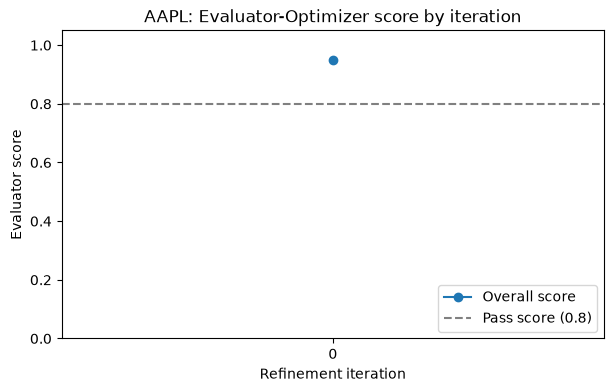

In [ ]:
# Score by iteration

import matplotlib.pyplot as plt


def plot_evaluation_history(
    result: dict,
    title: str
) -> None:
    """Plot the overall evaluator score for each iteration."""

    history = pd.DataFrame(
        result["history"]
    )

    fig, ax = plt.subplots(
        figsize=(7, 4)
    )

    ax.plot(
        history["iteration"],
        history["overall"],
        marker="o",
        label="Overall score"
    )

    ax.axhline(
        PASS_SCORE,
        linestyle="--",
        color="gray",
        label=f"Pass score ({PASS_SCORE})"
    )

    ax.set_xticks(
        history["iteration"]
    )

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Refinement iteration")
    ax.set_ylabel("Evaluator score")
    ax.set_title(title)
    ax.legend(loc="lower right")

    plt.show()


plot_evaluation_history(
    member3_result,
    f"{member3_result['symbol']}: "
    "Evaluator-Optimizer score by iteration"
)

In [ ]:
print(
    "Final version: iteration",
    member3_result["final_iteration"]
)

print(
    "Final score:",
    member3_result["final_score"]
)

print()
print(
    member3_result["final_report"]
)

Final version: iteration 0
Final score: 0.95

## Company
**Company/ticker:** AAPL. No further company background was provided.

## News Analysis
The supplied record contains **0 articles** and no news summary, events, or entities. News sentiment and potential investor relevance therefore cannot be assessed from the available information.

## Earnings Analysis
The listed EPS estimate is **$1.98**. Reported EPS, surprise percentage, revenue, financial performance, and company guidance are unavailable.

The earnings entry is dated **October 29, 2026**, after the current date of **October 4, 2026**. Based on the supplied information, this appears to be a future earnings date, not a completed report.

## Market Analysis
- **Current price:** 333.69
- **30-day price change:** +1.67%
- **P/E ratio:** 38.2672 (about 38.3)

The reported 30-day change is positive. The P/E figure is available, but no historical, peer, or expected-earnings comparisons were supplied to put it in context.

## Researc

## Refinement Test

The Member 2 draft can pass on the first evaluation. This test adds
unsupported claims and investment advice to the draft on purpose, to show
the evaluator rejecting a report and the optimizer repairing it.

In [ ]:
# Deliberately flawed draft: invented figures and buy advice

flawed_output = dict(member2_output)

flawed_output["draft_report"] = (
    member2_output["draft_report"]
    + "\n\n"
    + "The company reported EPS of $2.45, beating estimates "
    + "by 24%. Revenue grew 18% year over year. Analysts are "
    + "overwhelmingly bullish after strong product news. "
    + "Investors should buy the stock now."
)

flawed_result = run_evaluator_optimizer(
    flawed_output
)

pd.DataFrame(
    flawed_result["history"]
)[
    ["iteration"]
    + EVALUATION_CRITERIA
    + ["overall", "passed"]
]

,iteration,grounding,completeness,clarity,limitations,overall,passed
0,0,0.2,0.95,0.80,0.65,0.650,False
1,1,1.0,0.80,0.95,0.95,0.925,True


In [ ]:
print_evaluation_feedback(
    flawed_result
)

Iteration: 0 | Overall: 0.65 | Passed: False

Issues:
- The final paragraph claims reported EPS was $2.45 and beat estimates by 24%; neither figure is supported, and reported EPS and surprise are unavailable.
- The final paragraph claims revenue grew 18% year over year, but no revenue figures or growth data were supplied.
- The claims that analysts are overwhelmingly bullish and that strong product news exists are unsupported; the news record contains 0 articles.
- The recommendation to buy the stock is unsupported investment advice.

Feedback:
- Delete the final paragraph, or replace it with the supplied facts: EPS estimate is $1.98; reported EPS, surprise, revenue, guidance, and financial performance are unavailable.
- State that no news sentiment or analyst views can be assessed from the supplied record.
- Remove the buy recommendation. Keep the market discussion limited to the supplied price, 30-day change, and P/E ratio, without inferring a trading action.

Iteration: 1 | Overall:

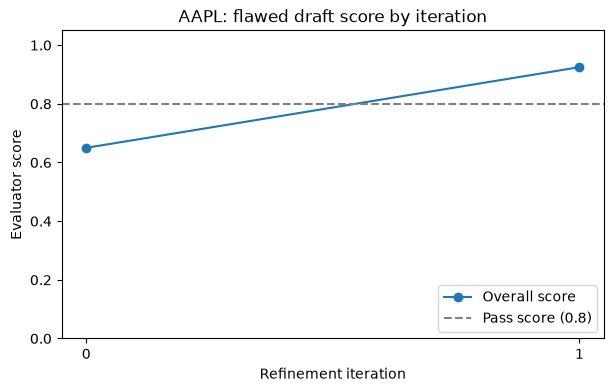

In [ ]:
plot_evaluation_history(
    flawed_result,
    f"{flawed_result['symbol']}: "
    "flawed draft score by iteration"
)

In [241]:
for symbol in ['AAPL', 'MSFT', 'NVDA']:
    print(f'\nFetching fresh news for {symbol}...')
    articles = fetch_financial_news(symbol)
    print(f'Articles found: {len(articles)}')
    for i, article in enumerate(articles[:3], 1):
        print(f'  {i}. {article["title"]} ({article["publisher"]})')


Fetching fresh news for AAPL...
Articles found: 5
  1. Apple cuts iPhone18 Pro component orders amid sluggish demand- Nikkei (Yahoo Finance RSS)
  2. Apple Names a New M&A Chief: What It Means for $100 Billion a Year in Buybacks (Yahoo Finance RSS)
  3. Elon Musk Will ‘Eventually’ Make a Phone, Says Gene Munster: Starlink Device Will Be a ‘Bigger Problem’ for Apple, Samsung (Yahoo Finance RSS)

Fetching fresh news for MSFT...
Articles found: 5
  1. Stocktwits AI Roundup: OpenAI Revenue Woes Rattle Chip Stocks, SoftBank Hunts $100B, Microsoft Goes AI-First (Yahoo Finance RSS)
  2. Microsoft and Adobe Face a Green Card Sponsorship Freeze: What Investors Should Watch (Yahoo Finance RSS)
  3. Zacks Investment Ideas feature highlights: Microsoft, Dell, HP, Lenovo and Nvidia (Yahoo Finance RSS)

Fetching fresh news for NVDA...
Articles found: 5
  1. Asian stocks mostly up as traders weigh AI, oil dips after surge (Yahoo Finance RSS)
  2. Stocktwits AI Roundup: OpenAI Revenue Woes Rattle Chi

In [ ]:
print(
    "Final version: iteration",
    flawed_result["final_iteration"]
)

print(
    "Final score:",
    flawed_result["final_score"]
)

print()
print(
    flawed_result["final_report"]
)

Final version: iteration 1
Final score: 0.925

## Company
**Company/ticker:** AAPL. No further company background was provided.

## News Analysis
The supplied record contains **0 articles** and no news summary, events, or entities. News sentiment, investor relevance, and analyst views cannot be assessed from the available information.

## Earnings Analysis
The listed EPS estimate is **$1.98**. Reported EPS, surprise, revenue, guidance, and financial performance are unavailable.

The earnings entry is dated **October 29, 2026**, after the current date of **October 4, 2026**. Based on the supplied information, it appears to be a future earnings date.

## Market Analysis
- **Current price:** 333.69
- **30-day price change:** +1.67%
- **P/E ratio:** 38.2672 (about 38.3)

## Research Limitations
The supplied information includes no news articles, analyst views, reported earnings results, revenue figures, guidance, or detailed price history. Trading volume, benchmark performance, and valuati